# Week 3: Tree Family Models

## Objective

This notebook explores tree-based machine learning models for predicting concrete compressive strength using the UCI Concrete dataset.

Models explored:
- Decision Tree Regressor
- Bagging Regressor
- Random Forest Regressor
- Extra Trees Regressor

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Step 1: Load Dataset

Loaded the UCI Concrete Compressive Strength dataset for tree-family machine learning analysis.

In [2]:
df = pd.read_excel("uci_concrete_data.xlsx")

df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,172.38,13.610000,172.37,156.760000,4.140000,1006.30000,856.400000,14.000000,29.750889
1,289.00,0.000000,0.00,192.000000,0.000000,913.20000,895.300000,28.000000,25.573354
2,349.00,0.000000,0.00,192.000000,0.000000,1056.00000,809.000000,3.000000,15.871738
3,186.20,124.100000,0.00,185.700000,0.000000,1083.40000,764.300000,7.000000,7.995853
4,NaN,81.031576,NaN,153.423861,6.545475,1079.50586,810.732259,22.280599,58.561221


## Step 2: Dataset Information

Checking dataset shape, column names, and data types.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(1080, 9)

Column Names:
Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

Data Types:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        fl

## Step 3: Missing Values and Duplicate Check

Checking dataset quality before model training.

In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64

Duplicate Rows:
25


## Step 4: Data Cleaning

Handling missing values and removing duplicate rows.

In [5]:
# Fill missing values using column mean
df = df.fillna(df.mean())

# Remove duplicate rows
df = df.drop_duplicates()

# Check final dataset shape
print("New Dataset Shape:")
print(df.shape)

New Dataset Shape:
(1055, 9)


## Step 5: Feature Selection

Separating input features and target variable.

In [8]:
# Display all column names
print(df.columns.tolist())

# Input features
X = df.iloc[:, :-1]

# Target variable
y = df.iloc[:, -1]

# Display shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']
X Shape: (1055, 8)
y Shape: (1055,)


## Step 6: Train-Test Split

Splitting the dataset into training and testing sets.

In [9]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (844, 8)
X_test Shape: (211, 8)
y_train Shape: (844,)
y_test Shape: (211,)


## Step 7: Decision Tree Model

Training a Decision Tree Regressor model.

In [10]:
# Create Decision Tree model

decision_tree = DecisionTreeRegressor(
    random_state=42
)

# Train model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Step 8: Model Evaluation

Evaluating Decision Tree model performance using regression metrics.

In [11]:
# Calculate evaluation metrics

mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

# Print results
print("Decision Tree Results")
print("----------------------")

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
----------------------
MAE: 4.477439893144056
RMSE: 7.058110491352687
R2 Score: 0.8084426591071858


## Step 9: Random Forest Model

Training and evaluating Random Forest Regressor.

In [12]:
# Create Random Forest model

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
random_forest.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

# Print results
print("Random Forest Results")
print("----------------------")

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
----------------------
MAE: 3.8711228080851816
RMSE: 5.591219918561752
R2 Score: 0.879791537205105


## Step 10: Extra Trees Model

Training and evaluating Extra Trees Regressor.

In [13]:
# Create Extra Trees model

extra_tree = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
extra_tree.fit(X_train, y_train)

# Predictions
y_pred_et = extra_tree.predict(X_test)

# Evaluation
mae_et = mean_absolute_error(y_test, y_pred_et)

rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))

r2_et = r2_score(y_test, y_pred_et)

# Print results
print("Extra Trees Results")
print("-------------------")

print("MAE:", mae_et)
print("RMSE:", rmse_et)
print("R2 Score:", r2_et)

Extra Trees Results
-------------------
MAE: 3.119662742997622
RMSE: 4.876493418603682
R2 Score: 0.9085597975155009


## Step 12: Quantile Random Forest

Training Quantile Random Forest model.

In [15]:
from quantile_forest import RandomForestQuantileRegressor

# Model
qrf = RandomForestQuantileRegressor(
    n_estimators=100,
    random_state=42
)

# Train
qrf.fit(X_train, y_train)

# Predict
y_pred_qrf = qrf.predict(X_test)

# Evaluation
mae_qrf = mean_absolute_error(y_test, y_pred_qrf)

rmse_qrf = np.sqrt(mean_squared_error(y_test, y_pred_qrf))

r2_qrf = r2_score(y_test, y_pred_qrf)

# Results
print("Quantile Random Forest Results")
print("MAE:", mae_qrf)
print("RMSE:", rmse_qrf)
print("R2 Score:", r2_qrf)

Quantile Random Forest Results
MAE: 3.3645600779820706
RMSE: 5.487173708981901
R2 Score: 0.8842237943594797


## Step 13: Final Model Comparison

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Quantile Random Forest"
    ],

    "R2 Score": [
        r2_dt,
        r2_rf,
        r2_et,
        r2_qrf
    ],

    "RMSE": [
        rmse_dt,
        rmse_rf,
        rmse_et,
        rmse_qrf
    ]
})

comparison

,Model,R2 Score,RMSE
0,Decision Tree,0.808443,7.058110
1,Random Forest,0.879792,5.591220
2,Extra Trees,0.908560,4.876493
3,Quantile Random Forest,0.884224,5.487174


Step 14: Cross Validation

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    extra_tree,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:")
print(cv_scores)

print("\nAverage R2 Score:")
print(cv_scores.mean())

Cross Validation R2 Scores:
[0.84906334 0.90667349 0.91807747 0.92358033 0.92512025]

Average R2 Score:
0.9045029754123695


Step 15: Hyperparameter Tuning using GridSearchCV

In [18]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter combinations
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=extra_tree,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred_best = best_model.predict(X_test)

# Evaluation
best_r2 = r2_score(y_test, y_pred_best)

best_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

# Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R2 Score:")
print(best_r2)

print("\nBest RMSE:")
print(best_rmse)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}

Best R2 Score:
0.8975002561794014

Best RMSE:
5.162980001716137


Step 16: Final Performance Report Table


In [19]:
final_report = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Quantile Random Forest"
    ],

    "MAE": [
        mae_dt,
        mae_rf,
        mae_et,
        mae_qrf
    ],

    "RMSE": [
        rmse_dt,
        rmse_rf,
        rmse_et,
        rmse_qrf
    ],

    "R2 Score": [
        r2_dt,
        r2_rf,
        r2_et,
        r2_qrf
    ]
})

final_report

,Model,MAE,RMSE,R2 Score
0,Decision Tree,4.477440,7.058110,0.808443
1,Random Forest,3.871123,5.591220,0.879792
2,Extra Trees,3.119663,4.876493,0.908560
3,Quantile Random Forest,3.364560,5.487174,0.884224


Step 17: Residual Plot

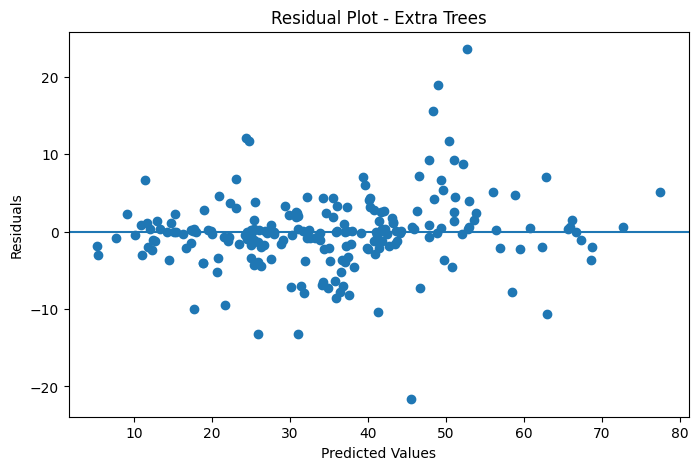

In [20]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred_et

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_et, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot - Extra Trees")

plt.show()